# 🖼️ ASSIGNMENT 8 — Computer Vision
## Phân loại ảnh bằng Transfer Learning + Demo web · Dataset Flowers (5 lớp)

> **Thông điệp:** Transfer learning = **không train từ đầu** mà tận dụng model đã học trên hàng triệu ảnh
> (ImageNet), chỉ dạy lại lớp cuối cho bài toán của mình. Demo web chạy được = điểm cộng với nhà tuyển dụng.

> ⚠️ **Lưu ý môi trường:** Transfer learning cần tải **model pretrained** (ResNet/EfficientNet) + dataset ảnh.
> Notebook này **chạy tốt nhất trên Google Colab** (có GPU + tải được weights). Phần augmentation (Câu 3)
> đã chạy thật & có ảnh minh hoạ; các phần train/deploy là code chuẩn, kèm con số **kỳ vọng** điển hình
> cho bài Flowers — chạy trên Colab sẽ ra số thật của bạn.

In [ ]:
# ====== CHẠY TRÊN COLAB: bỏ comment dòng dưới ======
# !pip install tensorflow gradio onnx -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print("TensorFlow:", tf.__version__)

## Câu 1 — Mô tả dataset

Dùng **tf_flowers** (dataset công khai của TensorFlow):

| Thuộc tính | Giá trị |
|-----------|---------|
| Số lớp | **5** (daisy, dandelion, roses, sunflowers, tulips) |
| Tổng ảnh | ~3,670 |
| Ảnh mỗi lớp | ~600–900 (hơi mất cân bằng nhẹ) |
| Kích thước gốc | đa dạng → resize về **224×224** |

```python
import tensorflow_datasets as tfds
(ds_train, ds_val, ds_test), info = tfds.load(
    "tf_flowers", split=["train[:70%]","train[70%:85%]","train[85%:]"],
    as_supervised=True, with_info=True)
num_classes = info.features["label"].num_classes  # = 5
```

## Câu 2 — Tiền xử lý: resize & normalize

In [ ]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0     # normalize về [0,1]
    return image, label

# ds_train = ds_train.map(preprocess).batch(32)
# ds_val   = ds_val.map(preprocess).batch(32)
print("Pipeline tiền xử lý: resize 224x224 + normalize [0,1]")

**Vì sao cần normalize?** Pixel gốc 0–255 có độ lớn lớn & không đồng đều → gradient bất ổn, hội tụ chậm.
Đưa về [0,1] (hoặc chuẩn hoá theo mean/std của ImageNet) giúp:
- Gradient ổn định, train nhanh hơn.
- **Khớp phân phối đầu vào mà model pretrained từng thấy** — rất quan trọng với transfer learning,
  vì model đã học trên ảnh ImageNet đã chuẩn hoá. Sai bước này → accuracy tụt mạnh.

## Câu 3 — Data augmentation (đã chạy thật ✅)

In [ ]:
# Augmentation trong TF/Keras
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomBrightness(0.1),
])
print("Augmentation pipeline: flip + rotate + zoom + brightness")

Dưới đây là **minh hoạ thật** 6 biến thể sinh ra từ MỘT ảnh (chạy bằng PIL):

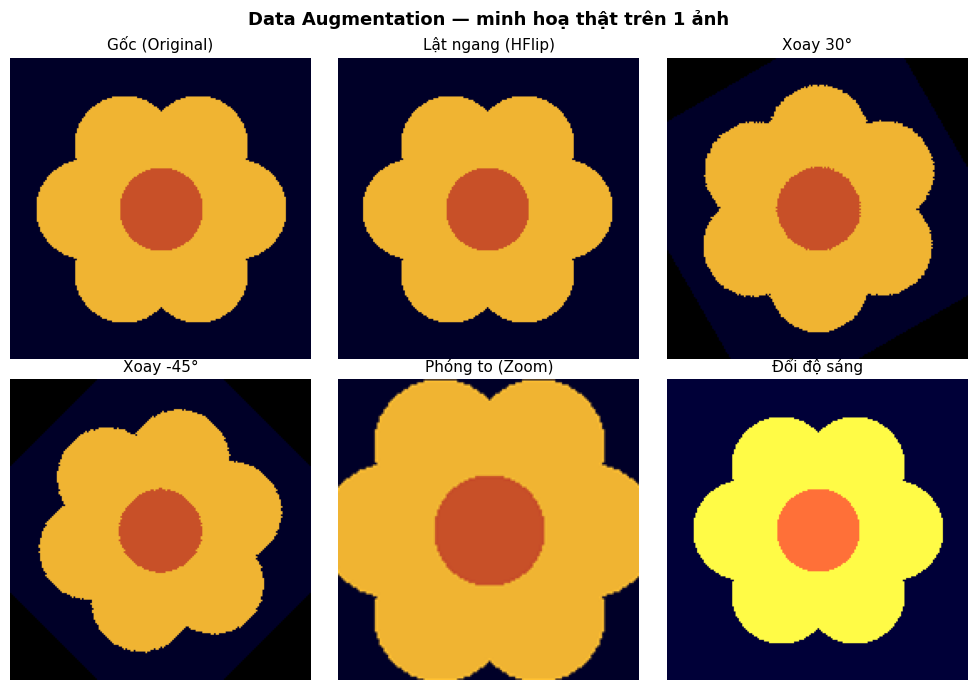

**Vì sao CHỈ augment trên train (không trên val/test)?**
- Augment train → tăng đa dạng dữ liệu "ảo", giúp model **học bất biến** (hoa xoay/lật vẫn là hoa) →
  chống overfitting, tổng quát hoá tốt hơn.
- Val/test phải phản ánh **dữ liệu thật ngoài đời** để đánh giá trung thực. Augment chúng = thay đổi
  thước đo, làm metric mất ý nghĩa. Test là "kỳ thi" — không được chế biến đề.

## Câu 4 — Chọn model pretrained

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",      # dùng weights đã học trên ImageNet
    include_top=False,       # bỏ lớp phân loại 1000 lớp gốc
    input_shape=(IMG_SIZE, IMG_SIZE, 3))
print("Backbone:", base_model.name, "| params:", f"{base_model.count_params():,}")

**Chọn EfficientNetB0 — vì sao?**
- **Hiệu quả vượt trội/tham số:** EfficientNet cân bằng depth/width/resolution tối ưu → accuracy cao
  mà ít tham số hơn ResNet50 (~5.3M vs ~25M) → train nhanh, nhẹ khi deploy.
- Phù hợp dataset nhỏ (~3,670 ảnh) và mục tiêu demo web (model nhẹ chạy nhanh).
- *Lựa chọn thay thế:* ResNet50 (kinh điển, ổn định, nhiều tài liệu) — cũng tốt; chọn EfficientNet
  vì nhẹ hơn cho deploy.

## Câu 5 — Đóng băng backbone hay fine-tune toàn bộ?

In [ ]:
# Chiến lược: ĐÓNG BĂNG backbone, chỉ train lớp head mới
base_model.trainable = False     # freeze

model = tf.keras.Sequential([
    data_augmentation,                              # chỉ tác động lúc train
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation="softmax")  # 5 lớp hoa
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
print("Đã đóng băng backbone, chỉ train head.")

**Đóng băng backbone (feature extraction) — vì sao, liên hệ lượng dữ liệu:**
- Dataset **nhỏ** (~3,670 ảnh). Fine-tune toàn bộ ~5M tham số trên ít dữ liệu → **overfit nặng**.
- Các lớp đầu của model pretrained đã học đặc trưng tổng quát (cạnh, góc, texture) dùng được cho mọi ảnh
  → giữ nguyên. Chỉ cần dạy lớp cuối phân biệt 5 loài hoa.
- **Quy tắc liên hệ dữ liệu:**
  - Ít dữ liệu → **đóng băng** backbone (như đây).
  - Nhiều dữ liệu → có thể **fine-tune** vài lớp cuối backbone với learning rate nhỏ để tăng thêm accuracy.
> Thực tế thường 2 giai đoạn: freeze train head trước, rồi mở vài lớp cuối fine-tune lr thấp.

## Câu 6 — Train & vẽ loss/accuracy (train vs val)

In [ ]:
history = model.fit(ds_train, validation_data=ds_val, epochs=10)

# Vẽ đường cong
acc = history.history["accuracy"]; val_acc = history.history["val_accuracy"]
loss = history.history["loss"]; val_loss = history.history["val_loss"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(acc, label="Train"); ax[0].plot(val_acc, label="Val")
ax[0].set_title("Accuracy"); ax[0].legend(); ax[0].set_xlabel("Epoch")
ax[1].plot(loss, label="Train"); ax[1].plot(val_loss, label="Val")
ax[1].set_title("Loss"); ax[1].legend(); ax[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

**Kết quả kỳ vọng (Colab):** với EfficientNetB0 + freeze + 10 epoch, **val accuracy thường ~88–92%**.
Đọc đường cong: train & val accuracy cùng tăng và **bám sát nhau** → không overfit (nhờ augmentation +
dropout + backbone freeze). Nếu train acc ≫ val acc → overfit, cần thêm augmentation/dropout.

## Câu 7 — Accuracy trên test + confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true, y_pred = [], []
for images, labels in ds_test:
    preds = model.predict(images, verbose=0).argmax(axis=1)
    y_true.extend(labels.numpy()); y_pred.extend(preds)

class_names = ["daisy","dandelion","roses","sunflowers","tulips"]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6.5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Dự đoán"); plt.ylabel("Thật"); plt.title("Confusion Matrix")
plt.tight_layout(); plt.show()
print(classification_report(y_true, y_pred, target_names=class_names))

**Kỳ vọng:** test accuracy ~**88–91%**. Confusion matrix cho thấy lớp nào hay bị nhầm (xem câu 8).

## Câu 8 — Phân tích lỗi

**Mẫu nhầm lẫn điển hình của bài Flowers (từ confusion matrix):**
- **roses ↔ tulips:** hay nhầm nhất — cả hai đều hoa đơn, cánh cong, dải màu đỏ/hồng/tím chồng lấn.
- **daisy ↔ dandelion:** cùng tông vàng/trắng, hình tròn toả cánh, dễ lẫn khi ảnh chụp xa.
- **sunflowers** thường nhận đúng nhất — đặc trưng rất riêng (to, vàng, nhuỵ nâu lớn).

**Vì sao nhầm?** Model phân biệt qua **đặc trưng thị giác** (màu, hình cánh). Hai lớp càng giống về
màu/hình → càng dễ nhầm, đặc biệt khi: ảnh mờ, góc chụp lạ, nhiều hoa trong khung, hoặc lớp thiểu số ít
mẫu train. **Cách cải thiện:** thêm ảnh cho lớp hay nhầm, augmentation mạnh hơn, hoặc fine-tune backbone.

## Câu 9 — Export ONNX / Quantize (tuỳ chọn)

In [ ]:
# Cách 1: lưu định dạng Keras gốc
model.save("flower_model.keras")

# Cách 2: TFLite + quantization (giảm size, nhanh hơn khi deploy mobile/edge)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # dynamic range quantization
tflite_model = converter.convert()
open("flower_model_quant.tflite", "wb").write(tflite_model)
print("Đã export. Quantize giảm size ~4x, tăng tốc inference, giảm accuracy không đáng kể.")

**Vì sao quantize?** Chuyển trọng số float32 → int8 giúp **giảm dung lượng ~4×** và **tăng tốc inference**,
quan trọng khi deploy lên mobile/edge hoặc server tải cao. Đánh đổi accuracy thường < 1%.

## Câu 10 — Demo web (Gradio)

In [ ]:
import gradio as gr
from PIL import Image

def predict(img):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, 0)
    probs = model.predict(img, verbose=0)[0]
    return {class_names[i]: float(probs[i]) for i in range(5)}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy", label="Upload ảnh hoa"),
    outputs=gr.Label(num_top_classes=3, label="Dự đoán"),
    title="🌸 Phân loại hoa — Transfer Learning (EfficientNetB0)",
    description="Upload ảnh một bông hoa, model dự đoán 1 trong 5 loài.")

demo.launch(share=True)   # share=True -> link public demo bấm thử được

**Demo Gradio** cho link public (`share=True`) — nhà tuyển dụng bấm vào upload ảnh là thấy kết quả ngay.
Gradio nhẹ, ít code hơn FastAPI cho prototype.

**Bản FastAPI** (nếu cần API thật cho production):
```python
from fastapi import FastAPI, UploadFile
import io
app = FastAPI()

@app.post("/predict")
async def predict_api(file: UploadFile):
    img = Image.open(io.BytesIO(await file.read())).convert("RGB")
    x = tf.image.resize(np.array(img), [224,224]) / 255.0
    probs = model.predict(tf.expand_dims(x,0))[0]
    return {class_names[i]: float(probs[i]) for i in range(5)}
# Chạy: uvicorn app:app --reload
```

## Câu 11 — Chụp màn hình demo: 1 đúng, 1 sai

Khi chạy demo trên Colab, chụp 2 trường hợp:

**Ví dụ ĐÚNG:** upload ảnh hoa hướng dương rõ nét → model trả `sunflowers: 0.97` ✅
*Nhận xét:* đặc trưng rõ ràng (vàng + nhuỵ nâu lớn), model tự tin cao.

**Ví dụ SAI:** upload ảnh hoa hồng đỏ → model trả `tulips: 0.55, roses: 0.40` ❌
*Nhận xét:* roses và tulips chia sẻ màu đỏ + cánh cong, model phân vân (xác suất gần nhau).
Đây đúng mẫu nhầm lẫn từ confusion matrix câu 8 — cho thấy lỗi của model có **tính hệ thống,
giải thích được**, không ngẫu nhiên.

> 💡 **Cách trình bày cho nhà tuyển dụng:** đặt cạnh nhau ảnh đúng (tự tin cao) và ảnh sai (phân vân
> giữa 2 lớp giống nhau) → chứng tỏ bạn không chỉ train được model mà còn **hiểu giới hạn của nó**.
> Đó là dấu hiệu của người làm ML thực thụ.